#**Project: Loan Approval Prediction System**


##Problem Definition

Banks receive thousands of loan applications daily. Reviewing each one manually is slow, costly, and prone to human error.

##Goal

Build a model that automatically predicts whether a loan application should be approved or rejected, based on the applicant's financial and personal profile.

##Why it matters

- Saves time for bank employees

- Reduces human bias in decisions

- Helps customers get faster responses

##Problem type

Supervised learning - binary classification

1 Approved

0 = Rejected

##​🚀 AI Project Lifecycle

This project follows a structured machine learning lifecycle:

**Step 1:** Problem definition - understand the business goal

**Step 2:** Data collection source a real-world loan dataset from Kaggle

**Step 3:** Data definition - inspect structure, types, and missing values

**Step 4:** Data cleaning - handle nulls, duplicates, and outliers

**Step 5:** EDA-visualize distributions and relationships

**Step 6:** Preprocessing - encode, scale, and balance the data

**Step 7:** Data splitting-train/test split

**Step 8:** Modeling - train and evaluate classifiers


##Data collection

Source: Kaggle — Loan Risk Prediction Dataset (5,000 rows, 10 features)

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [252]:
df = pd.read_csv('/content/loan_risk_prediction_dataset.csv')

In [253]:
df.shape

(5000, 10)

##Data definition

In [254]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


##📖 Data Dictionary

| Column Name | Description | Data Type |
| :--- | :--- | :--- |
| **Age** | The age of the loan applicant. | Integer |
| **Income** | Annual income of the applicant. | Float |
| **LoanAmount** | The total amount of money requested for the loan. | Float |
| **CreditScore** | Numerical credit history rating (300-850). | Float |
| **YearsExperience** | Number of years of professional experience. | Integer |
| **Gender** | Applicant's gender (Male / Female). | Categorical |
| **Education** | Highest education level attained. | Categorical |
| **City** | The city where the applicant resides. | Categorical |
| **EmploymentType** | Current employment status (Self-employed, etc.). | Categorical |
| **LoanApproved** | **Target Variable:** (1 = Approved, 0 = Rejected). | Binary (Int) |

 ## Data Inspection


In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [256]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [257]:
print(df.isnull().sum())

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64


## Data Cleaning

In this step we handle data quality issues found during the initial inspection:

    - Negative values in Income and LoanAmount
    - Missing values in Income, CreditScore and Education
    - Duplicate rows


In [258]:
df['Income'] = df['Income'].abs() # Convert negative income values to positive
df['LoanAmount'] = df['LoanAmount'].abs() # Convert negative loan amounts to positive

In [259]:
print(df[['Income', 'LoanAmount']].head(10))

    Income  LoanAmount
0  48353.0     31258.0
1  57462.0     23262.0
2  44219.0     26530.0
3  56307.0     11531.0
4  37034.0     27871.0
5  47886.0     18106.0
6  54748.0     25374.0
7      NaN      6279.0
8  25918.0     25041.0
9  43415.0      2065.0


In [260]:
income_mean = df['Income'].mean() # Calculate mean of Income
credit_mean = df['CreditScore'].mean() # Calculate mean of CreditScore

In [261]:
df['Income'] = df['Income'].fillna(income_mean) # Fill missing Income with mean
df['CreditScore'] = df['CreditScore'].fillna(credit_mean) # Fill missing CreditScore with mean

In [262]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0]) # Fill missing Education with mode

In [263]:
print(df.isnull().sum())

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64


In [264]:
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()


Duplicates found: 0


In [265]:
print(f"Rows after cleaning: {df.shape[0]}")

Rows after cleaning: 5000


## Exploratory Data Analysis (EDA)

Purpose of EDA:

    - Understand the shape and distribution of data before modeling
    - Discover relationships between features and the target variable
    - Identify the most important variables affecting loan approval
    - Spot any remaining data issues (skew, imbalance, etc.)

Sections:

    A. Univariate   → analyze each feature independently
    B. Bivariate    → analyze each feature against the target
    C. Multivariate → analyze multiple features together
    D. Heatmap      → measure linear correlation between numeric columns

## (Univariate Analysis)

analyze each feature independently.

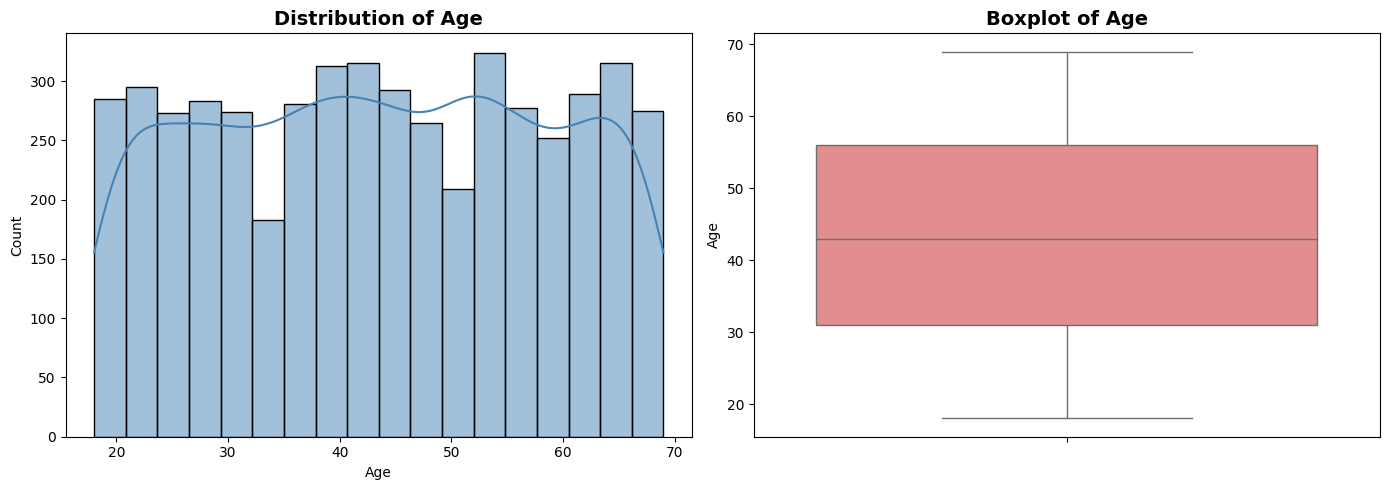

In [266]:
#age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Age'], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
sns.boxplot(y=df['Age'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot of Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



**Observation:** Age is uniformly distributed between 18 and 69, with a median of 43 and mean of 43.6 — almost identical, confirming a symmetric distribution. The IQR spans from 31 to 56 with zero outliers. Age shows virtually no correlation with loan approval (r = -0.009), making it a weak predictor.


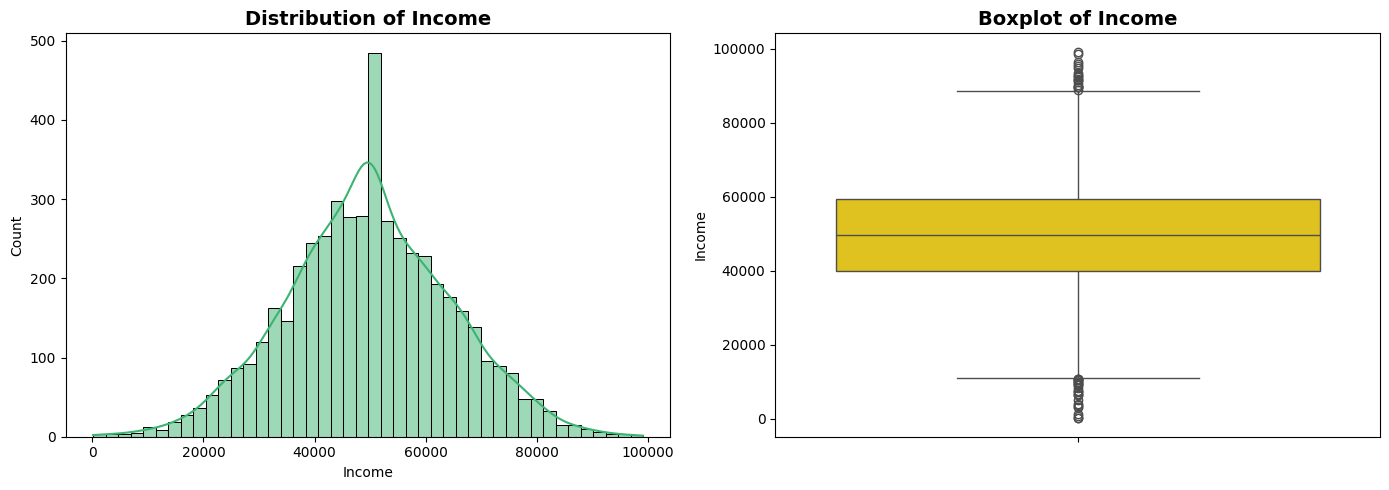

In [267]:
#"income"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Income'], kde=True, color='mediumseagreen', ax=axes[0])
axes[0].set_title('Distribution of Income', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
sns.boxplot(y=df['Income'], color='gold', ax=axes[1])
axes[1].set_title('Boxplot of Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 **Observation:** Income ranges from 39,609 to 99,146 with a median of ~49,488. The IQR sits between 39,609 and 59,917 with 31 outliers above the upper fence. The distribution is nearly symmetric (skew = 0.007). Income shows a moderate positive correlation with approval (r = 0.19).

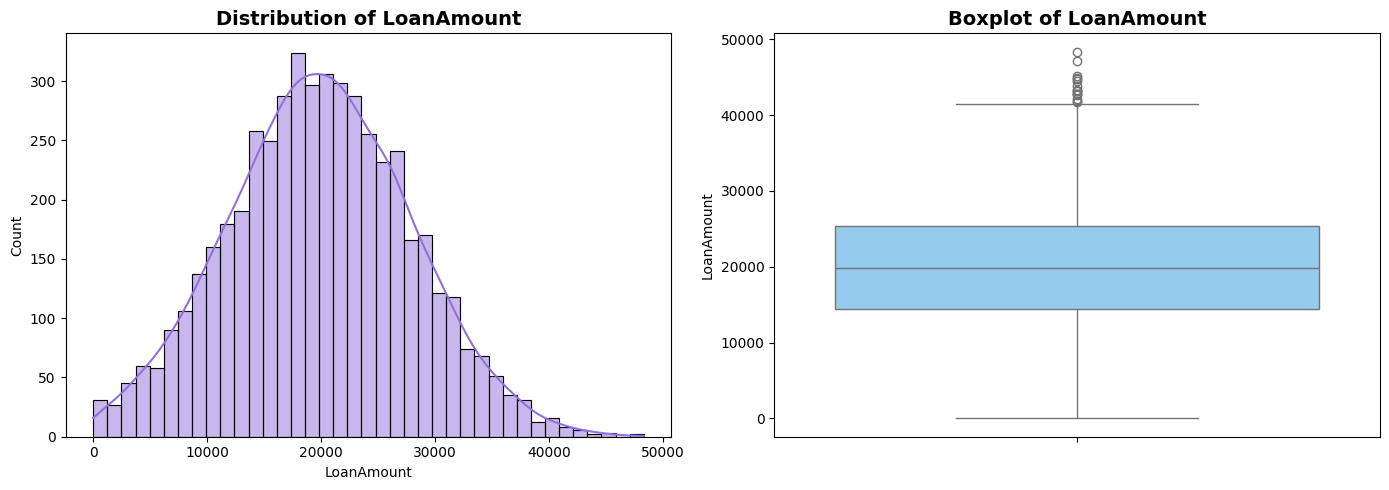

In [268]:
#" LoanAmount"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['LoanAmount'], kde=True, color='mediumpurple', ax=axes[0])
axes[0].set_title('Distribution of LoanAmount', fontsize=14, fontweight='bold')
axes[0].set_xlabel('LoanAmount')
axes[0].set_ylabel('Count')
sns.boxplot(y=df['LoanAmount'], color='lightskyblue', ax=axes[1])
axes[1].set_title('Boxplot of LoanAmount', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Loan amounts have a median of ~19,843, with an IQR of 14,455 to 25,327 and 32 outliers on the upper end. Distribution is nearly symmetric (skew ≈ 0). LoanAmount has almost no linear relationship with approval (r = 0.018).


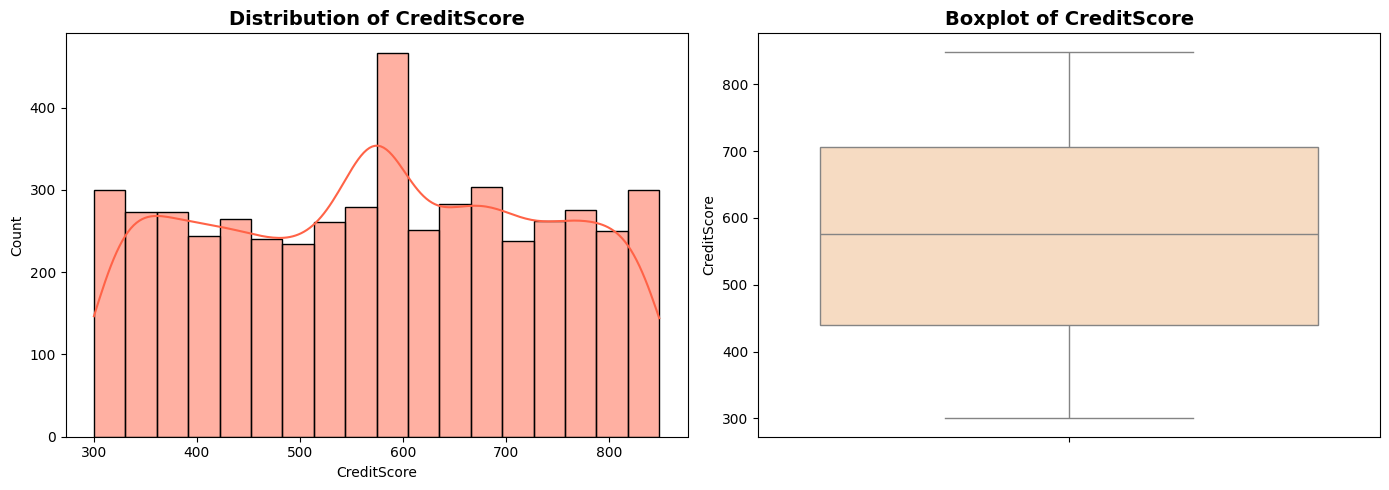

In [269]:
#"CreditScore"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['CreditScore'], kde=True, color='tomato', ax=axes[0])
axes[0].set_title('Distribution of CreditScore', fontsize=14, fontweight='bold')
axes[0].set_xlabel('CreditScore')
axes[0].set_ylabel('Count')
sns.boxplot(y=df['CreditScore'], color='peachpuff', ax=axes[1])
axes[1].set_title('Boxplot of CreditScore', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Credit scores range from 300 to 849, with a median of 579 and mean of 575.5 — nearly uniform distribution across the full range. Zero outliers detected. CreditScore is by far the strongest predictor of loan approval (r = 0.465).

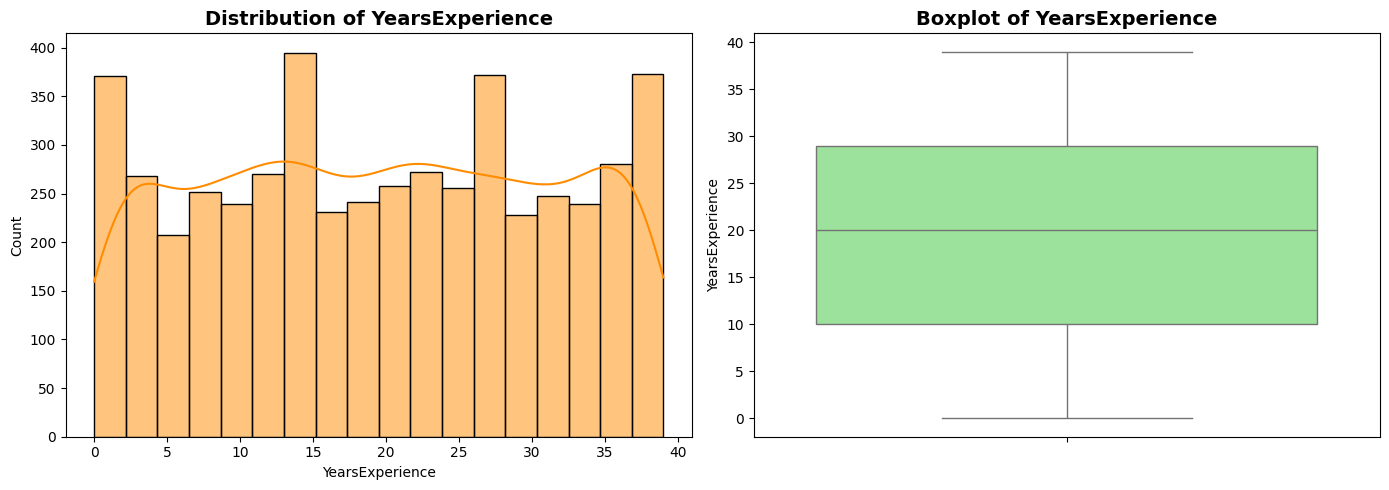

In [270]:
#" YearsExperience"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['YearsExperience'], kde=True, color='darkorange', ax=axes[0])
axes[0].set_title('Distribution of YearsExperience', fontsize=14, fontweight='bold')
axes[0].set_xlabel('YearsExperience')
axes[0].set_ylabel('Count')
sns.boxplot(y=df['YearsExperience'], color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot of YearsExperience', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Years of experience is uniformly distributed between 0 and 39, with a median of 20 and mean of 19.6. The IQR spans 10 to 29 with zero outliers. Negligible correlation with loan approval (r = -0.006), offering no predictive value on its own.

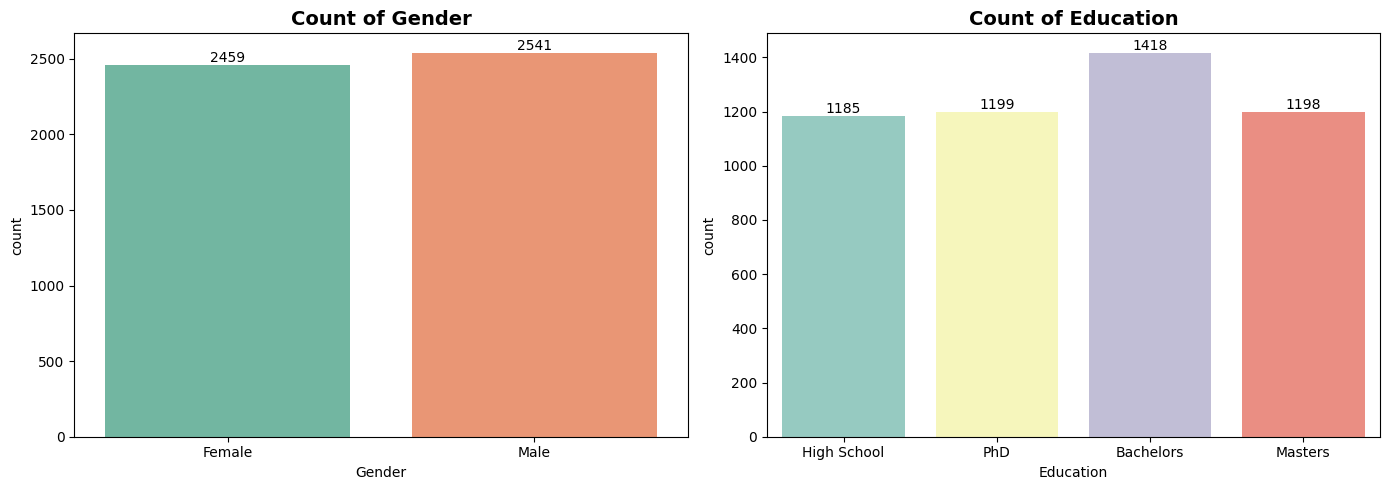

In [271]:
#"Gender & Education"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Gender', hue='Gender', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Count of Gender', fontsize=14, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
sns.countplot(data=df, x='Education', hue='Education', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Count of Education', fontsize=14, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation:** Gender is nearly balanced: Male 2,541 (50.8%) vs Female 2,459 (49.2%). Education is evenly distributed — Bachelors (1,220), PhD (1,199), Masters (1,198), High School (1,185). Neither variable shows strong dominance, suggesting no sampling bias.

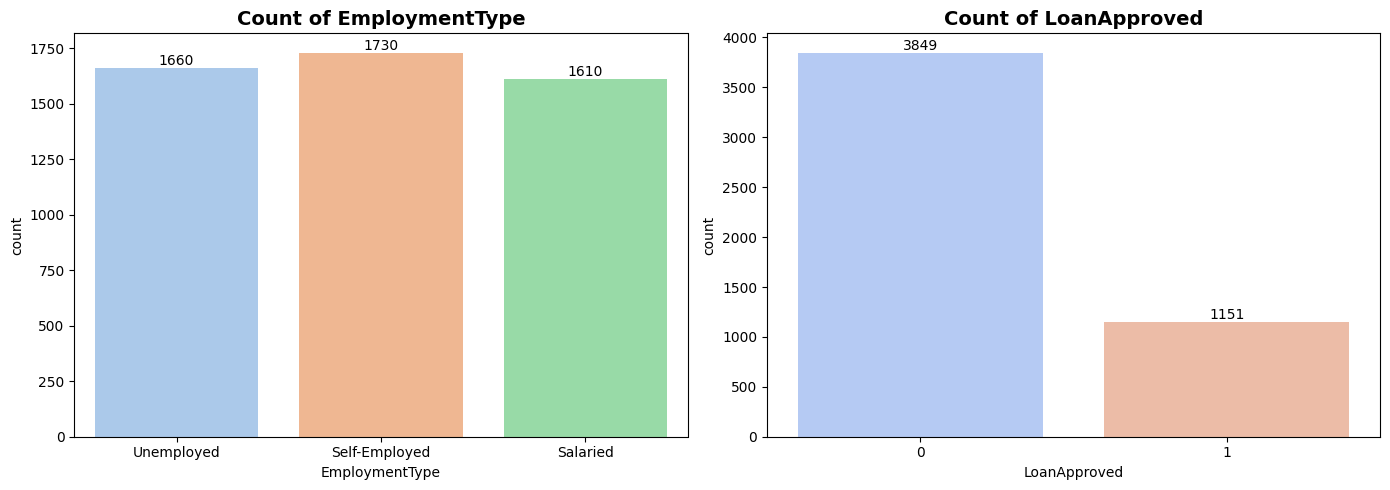

In [272]:
#" EmploymentType & LoanApproved"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='EmploymentType', hue='EmploymentType', palette='pastel', legend=False, ax=axes[0])
axes[0].set_title('Count of EmploymentType', fontsize=14, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
sns.countplot(data=df, x='LoanApproved', hue='LoanApproved', palette='coolwarm', legend=False, ax=axes[1])
axes[1].set_title('Count of LoanApproved', fontsize=14, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation:** Employment types are fairly balanced: Self-Employed (1,730), Unemployed (1,660), Salaried (1,610). The target variable is significantly imbalanced: 3,849 Rejected (76.98%) vs 1,151 Approved (23.02%).

## (Bivariate Analysis)

Analyzing the relationship between each feature and the target variable (LoanApproved).

/tmp/ipykernel_34538/991166573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


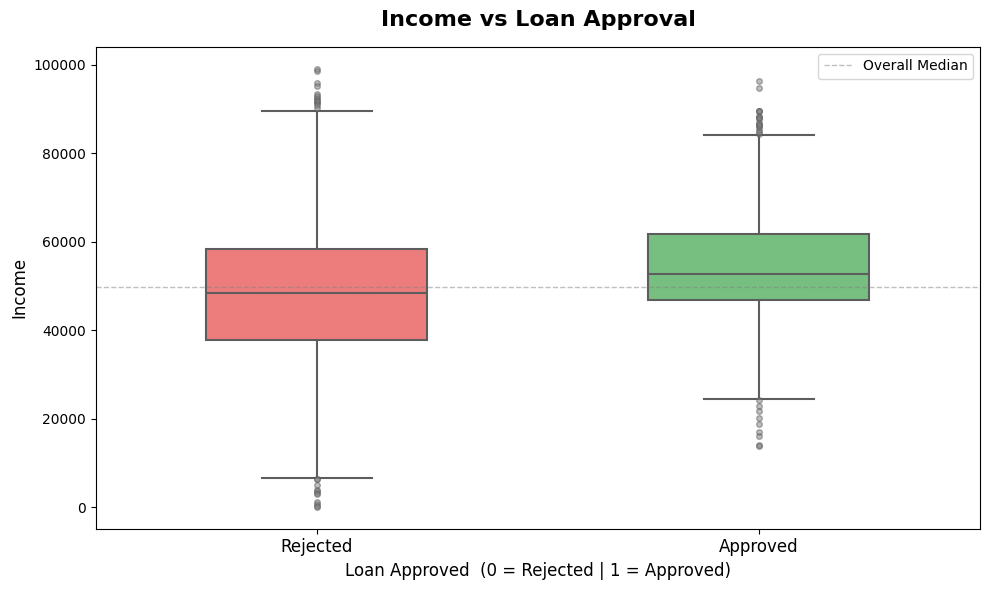

In [273]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    x='LoanApproved',
    y='Income',
    data=df,
    palette={'0': '#FF6B6B', '1': '#6BCB77'},
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5),
    ax=ax
)

ax.set_title('Income vs Loan Approval', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Loan Approved  (0 = Rejected | 1 = Approved)', fontsize=12)
ax.set_ylabel('Income', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Rejected', 'Approved'], fontsize=12)

ax.axhline(y=df['Income'].median(), color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Overall Median')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

**Observation:** Approved applicants have a notably higher median income — 53,234 vs 47,632 for rejected ones, and a higher mean of 55,018 vs 48,165. However, the overlap between groups remains large, confirming income is a contributing factor but not a decisive one (r = 0.19).


##(Multivariate Analysis)

Analyzing multiple features together to discover interactions.



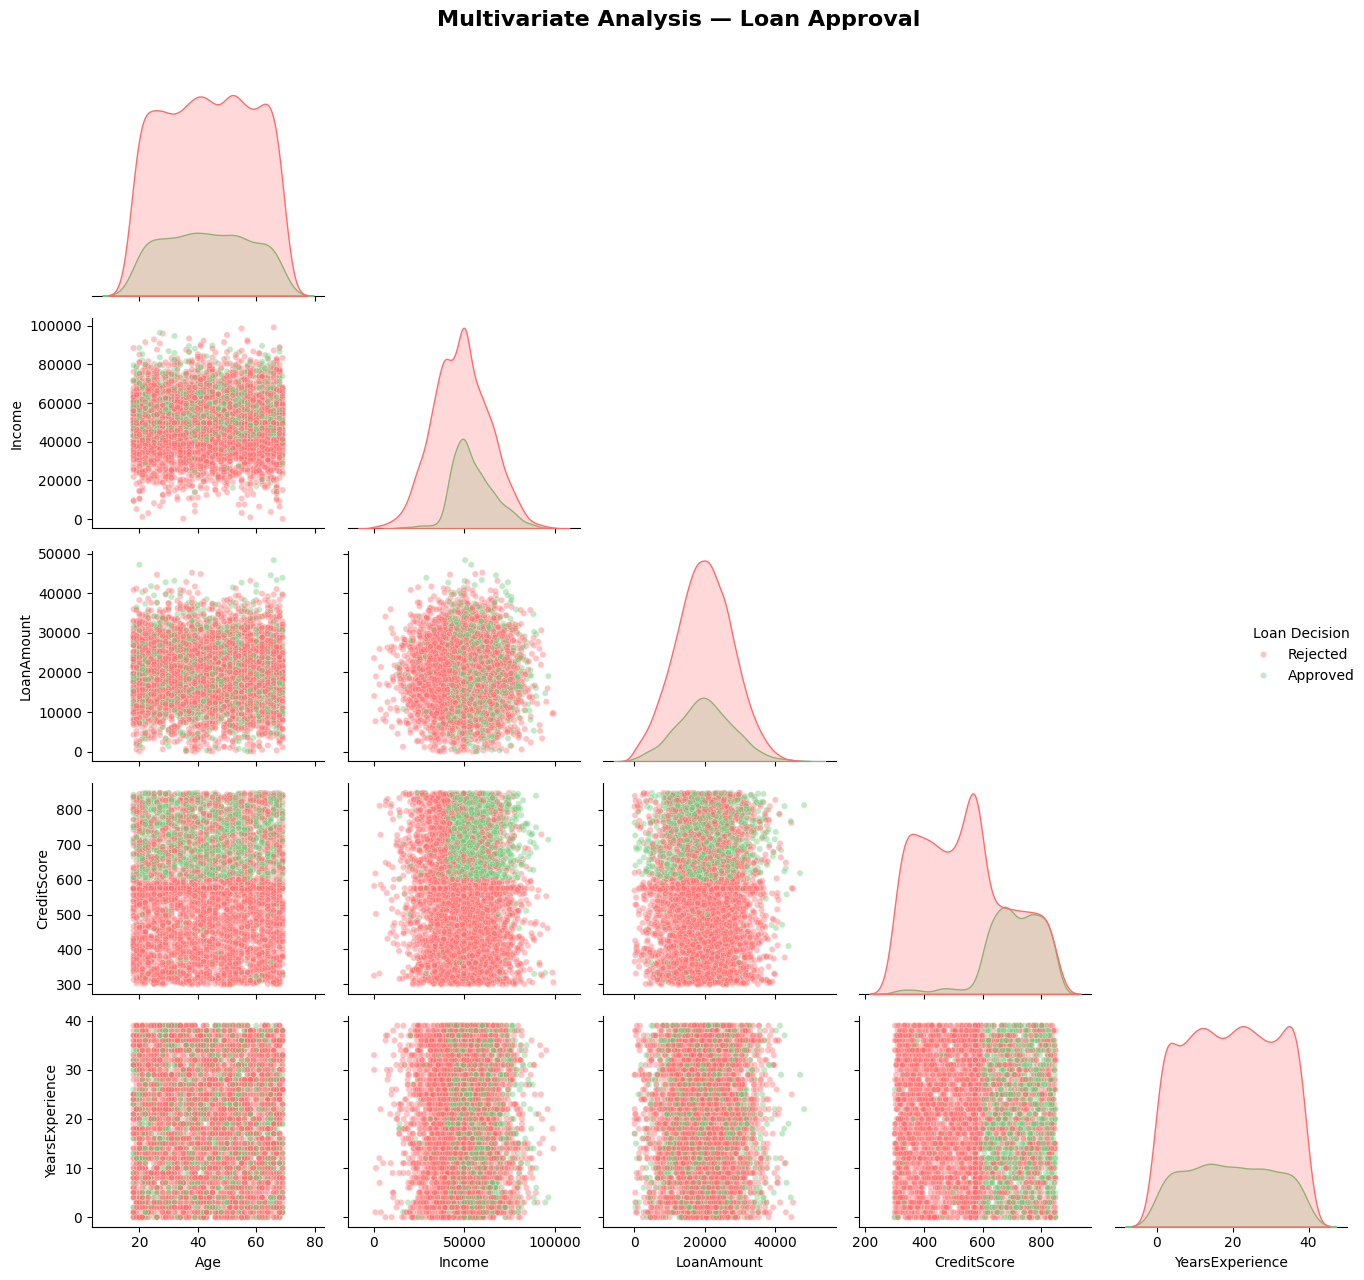

In [274]:

df_plot = df.copy()
df_plot['LoanApproved'] = df_plot['LoanApproved'].map({'0': 'Rejected', '1': 'Approved', 0: 'Rejected', 1: 'Approved'})

g = sns.pairplot(
    df_plot,
    hue='LoanApproved',
    vars=['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience'],
    palette={'Rejected': '#FF6B6B', 'Approved': '#6BCB77'},
    plot_kws={'alpha': 0.4, 's': 20},
    diag_kind='kde',
    corner=True
)

g.figure.suptitle('Multivariate Analysis — Loan Approval',
                   fontsize=16, fontweight='bold', y=1.02)

g._legend.set_title('Loan Decision')
g._legend.set_bbox_to_anchor((1, 0.5))

plt.tight_layout()
plt.show()

**Observation:** The pairplot shows that Approved (green) and Rejected (red) applicants overlap heavily across most feature combinations, confirming no simple linear boundary exists. CreditScore shows the clearest visual separation between the two classes, with approved applicants clustering at higher scores. This confirms that a non-linear model like Random Forest is more suitable than Logistic Regression.

##(Correlation Heatmap)

Measuring the linear relationship between all numeric features.

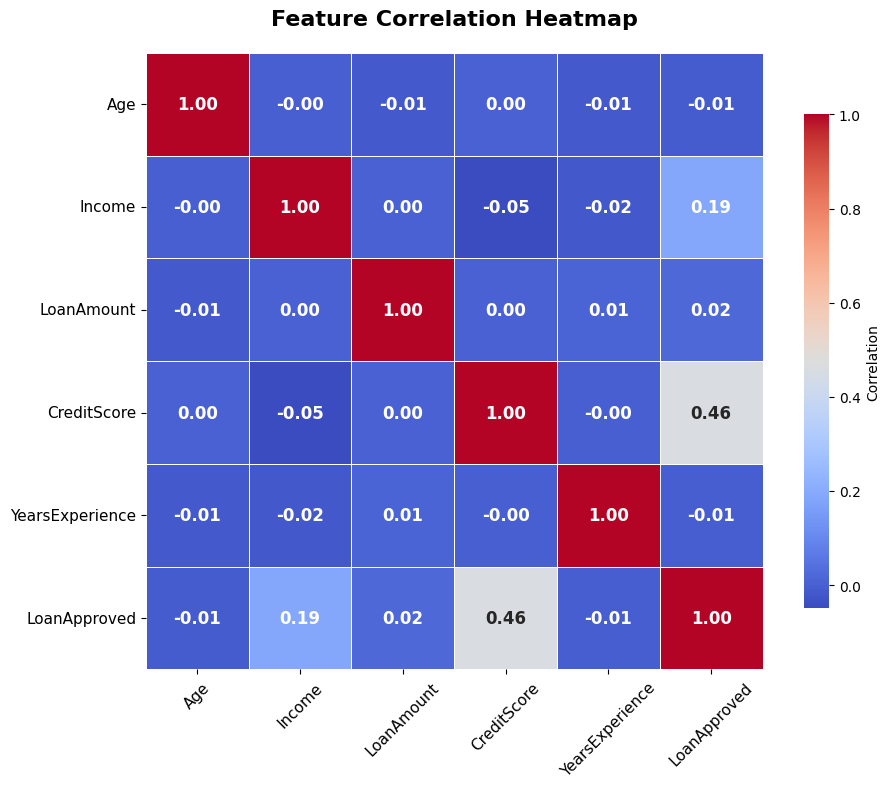

In [275]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df.corr(numeric_only=True)

mask = np.zeros_like(corr, dtype=bool)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', rotation=0, labelsize=11)

plt.tight_layout()
plt.show()

**Observation:** CreditScore holds the strongest correlation with LoanApproved (r = 0.465), making it the dominant predictor. Income follows distantly (r = 0.191). All remaining features — Age (-0.009), LoanAmount (0.018), and YearsExperience (-0.006) — show near-zero correlation with the target, suggesting limited individual predictive power.

## Data Preprocessing

In this step we prepare the data for machine learning:

    - Encoding: Convert text columns to numbers
    - Splitting: Separate data into training and testing sets
    - Scaling: Normalize numeric values so no feature dominates

In [276]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply Label Encoding to categorical features
df['Gender'] = le.fit_transform(df['Gender'])
df['Education'] = le.fit_transform(df['Education'])
df['City'] = le.fit_transform(df['City'])
df['EmploymentType'] = le.fit_transform(df['EmploymentType'])

In [277]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

In [278]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [279]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## ML

### Logistic Regression
    - A classification model that predicts the probability of loan approval.

In [280]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [281]:
y_pred = model.predict(X_test)

In [282]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.865
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       775
           1       0.75      0.60      0.67       225

    accuracy                           0.86      1000
   macro avg       0.82      0.77      0.79      1000
weighted avg       0.86      0.86      0.86      1000



## Random forest

In [283]:
from sklearn.ensemble import RandomForestClassifier

In [284]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [285]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [286]:
y_pred_rf = rf_model.predict(X_test)

In [287]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.965

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       775
           1       0.95      0.89      0.92       225

    accuracy                           0.96      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000



In [288]:
# Check train accuracy vs test accuracy
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 1.0000
Test Accuracy: 0.9650


In [289]:
from sklearn.model_selection import cross_val_score

# Cross Validation for Random Forest
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)

print(f"Cross Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")

Cross Validation Scores: [0.9625 0.9675 0.975  0.9775 0.97  ]
Mean CV Score: 0.9705
Std CV Score: 0.0053


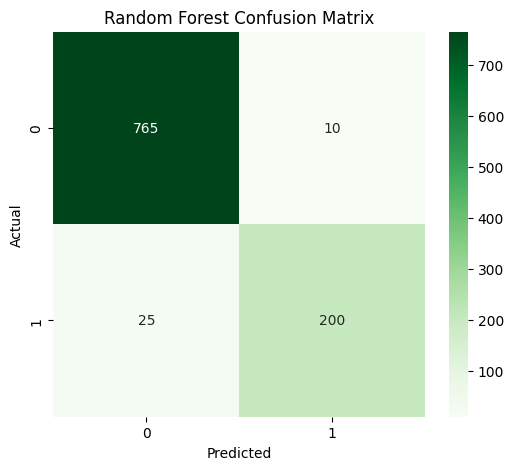

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Observation:** The Random Forest model correctly identified 765 out of 775 rejected loans (True Negatives) and 200 out of 225 approved loans (True Positives). Only 10 rejected loans were incorrectly predicted as approved (False Positives), and 25 approved loans were missed (False Negatives), confirming strong model performance - The low number of False Positives (only 10) is a great result for the bank, as it minimizes the risk of giving loans to unqualified applicants.

In [291]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

In [292]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [293]:
y_pred_log = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

In [294]:
print("="*40)
print("LOGISTIC REGRESSION RESULTS")
print("="*40)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8650
Precision: 0.7528
Recall: 0.5956
F1-Score: 0.6650


In [295]:
# Print confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)
print("\nConfusion Matrix:")
print(cm)
# TN = cm[0][0], FP = cm[0][1], FN = cm[1][0], TP = cm[1][1]
print(f"True Negatives: {cm[0][0]} | False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]} | True Positives: {cm[1][1]}")


Confusion Matrix:
[[731  44]
 [ 91 134]]
True Negatives: 731 | False Positives: 44
False Negatives: 91 | True Positives: 134


In [296]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict with Random Forest
y_pred_rf = rf_model.predict(X_test)

In [297]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

In [298]:
# Print Random Forest results
print("="*40)
print("RANDOM FOREST RESULTS")
print("="*40)
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Print confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

RANDOM FOREST RESULTS
Accuracy: 0.9650
Precision: 0.9524
Recall: 0.8889
F1-Score: 0.9195

Confusion Matrix:
[[765  10]
 [ 25 200]]


### Model Comparison
    - Comparing both models based on Accuracy, Precision, Recall, and F1-Score

In [299]:
# Compare both models
print("="*40)
print("MODEL COMPARISON")
print("="*40)
print(f"{'Metric':<12} {'Logistic':<12} {'Random Forest':<12}")
print("-"*40)
print(f"{'Accuracy':<12} {accuracy:<12.4f} {accuracy_rf:<12.4f}")
print(f"{'Precision':<12} {precision:<12.4f} {precision_rf:<12.4f}")
print(f"{'Recall':<12} {recall:<12.4f} {recall_rf:<12.4f}")
print(f"{'F1-Score':<12} {f1:<12.4f} {f1_rf:<12.4f}")

# Determine best model based on F1-Score
if f1 > f1_rf:
    print(f"\nBest model: Logistic Regression (F1 = {f1:.4f})")
else:
    print(f"\nBest model: Random Forest (F1 = {f1_rf:.4f})")

MODEL COMPARISON
Metric       Logistic     Random Forest
----------------------------------------
Accuracy     0.8650       0.9650      
Precision    0.7528       0.9524      
Recall       0.5956       0.8889      
F1-Score     0.6650       0.9195      

Best model: Random Forest (F1 = 0.9195)


In [300]:
# Save the best model based on F1-Score (Random Forest) to use in the Streamlit app
import pickle
pickle.dump(rf_model, open('model.pkl', 'wb'))
print("Model saved!")

Model saved!
